In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from textblob import TextBlob

In [18]:
data = pd.read_csv(r"F:\MySubjects\Projects\FakeNewsDetection\archive1\WELFake_Dataset.csv")

print(data.head())
print("Dataset Shape:", data.shape)
print("Columns:", data.columns)

   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
Dataset Shape: (72134, 4)
Columns: Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')


In [19]:
# Remove missing values
data = data.dropna()

print("\nFake vs Real News Count:")
print(data["label"].value_counts())


Fake vs Real News Count:
label
1    36509
0    35028
Name: count, dtype: int64


In [20]:
data["content"] = data["title"] + " " + data["text"]

print("\nSample News Content:\n")
print(data["content"].iloc[0][:500])


Sample News Content:

LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizer


In [21]:
X = data["content"]
y = data["label"]   # already numeric (0 = REAL, 1 = FAKE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 57229
Testing samples: 14308


In [22]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (57229, 220436)
TF-IDF Testing Shape: (14308, 220436)


In [23]:
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train_tfidf, y_train)

print("✅ Model Training Completed Successfully!")

✅ Model Training Completed Successfully!


In [24]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy: {:.2f}%".format(accuracy * 100))

print("\n📌 Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\n📌 Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 94.76%

📌 Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      7081
           1       0.94      0.96      0.95      7227

    accuracy                           0.95     14308
   macro avg       0.95      0.95      0.95     14308
weighted avg       0.95      0.95      0.95     14308


📌 Confusion Matrix:

[[6636  445]
 [ 305 6922]]


In [25]:
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive 😊"
    elif polarity < 0:
        return "Negative 😡"
    else:
        return "Neutral 😐"

In [26]:
sample_news = X_test.iloc[0]

print("📰 News Article:\n")
print(sample_news[:400])

print("\n💡 Sentiment:", get_sentiment(sample_news))

📰 News Article:

Live at Truthdig: Robert Scheer and Thomas Frank Talk About His New Book at 4 P.M. PDT Live at Truthdig: Robert Scheer and Thomas Frank Talk About His New Book at 4 P.M. PDT Posted on Oct 30, 2016 Eventbrite 
Truthdig editor in chief Robert Scheer sits down with political analyst Thomas Frank to discuss his new book “Listen Liberal: Whatever Happened to the Party of the People?” as well as the 201

💡 Sentiment: Positive 😊


In [27]:
def predict_news(news_text):

    news_vec = vectorizer.transform([news_text])
    prediction = model.predict(news_vec)[0]

    if prediction == 1:
        result = "FAKE NEWS ❌"
    else:
        result = "REAL NEWS ✅"

    sentiment = get_sentiment(news_text)

    print("\n==============================")
    print("📰 News Prediction Result")
    print("==============================")
    print("Fake/Real:", result)
    print("Sentiment:", sentiment)
    print("==============================\n")

In [28]:
sample_news = X_test.iloc[11]
predict_news(sample_news)


📰 News Prediction Result
Fake/Real: REAL NEWS ✅
Sentiment: Positive 😊



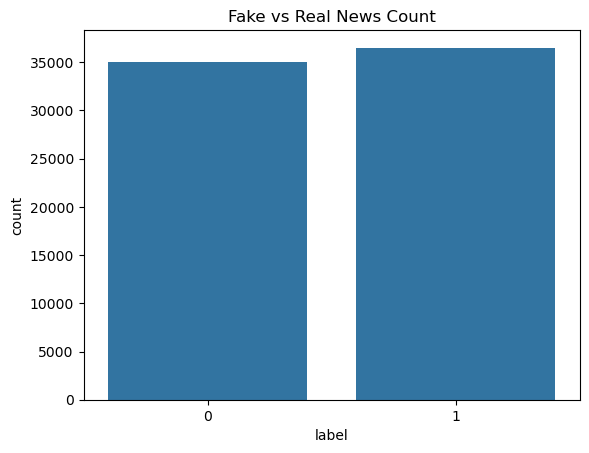

In [29]:
# Fake vs Real Count
sns.countplot(x=data["label"])
plt.title("Fake vs Real News Count")
plt.show()

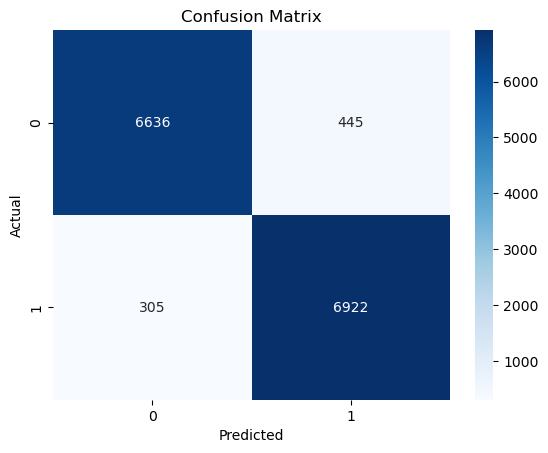

In [30]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

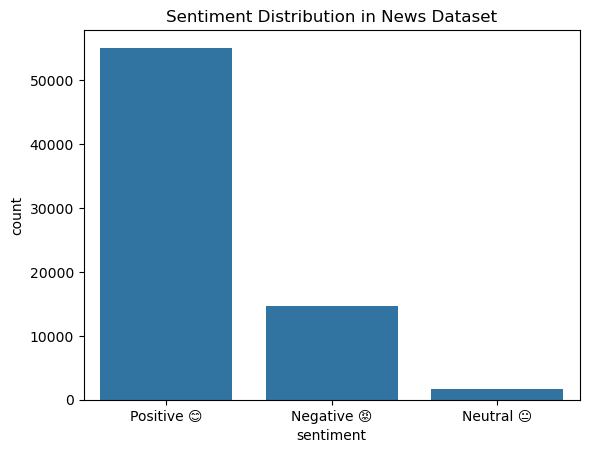

In [31]:
data["sentiment"] = data["content"].apply(get_sentiment)

sns.countplot(x=data["sentiment"])
plt.title("Sentiment Distribution in News Dataset")
plt.show()

In [32]:
predict_news("""
Breaking News: Scientists discovered a new technology
that may change artificial intelligence forever.
Experts say this could impact future research.
""")


📰 News Prediction Result
Fake/Real: FAKE NEWS ❌
Sentiment: Negative 😡



In [35]:
predict_news("""Scientists at NASA announced a new satellite mission aimed at studying climate change and monitoring ocean temperatures across the globe.""")


📰 News Prediction Result
Fake/Real: FAKE NEWS ❌
Sentiment: Positive 😊



In [36]:
predict_news("""The government has introduced a new digital learning platform to support students with online classes and interactive study materials.""")


📰 News Prediction Result
Fake/Real: REAL NEWS ✅
Sentiment: Positive 😊



In [37]:
predict_news("""India won the cricket series after defeating Australia in the final match with a strong performance from the bowling unit.""")


📰 News Prediction Result
Fake/Real: REAL NEWS ✅
Sentiment: Positive 😊



In [38]:
predict_news("""Secret scientists reveal that the moon is actually a giant artificial structure created by aliens thousands of years ago.""")


📰 News Prediction Result
Fake/Real: FAKE NEWS ❌
Sentiment: Negative 😡



In [39]:
predict_news("""A miracle drink discovered in a hidden village can instantly make people younger and cure all diseases without any medical proof.""")


📰 News Prediction Result
Fake/Real: FAKE NEWS ❌
Sentiment: Negative 😡



In [40]:
predict_news("""Breaking: Government plans to shut down the entire internet worldwide tomorrow according to anonymous sources.""")


📰 News Prediction Result
Fake/Real: FAKE NEWS ❌
Sentiment: Negative 😡



In [41]:
predict_news("""Weather is cloudy today in many cities.""")


📰 News Prediction Result
Fake/Real: FAKE NEWS ❌
Sentiment: Positive 😊



In [42]:
predict_news("""The meeting will be held at 10 AM tomorrow.""")


📰 News Prediction Result
Fake/Real: FAKE NEWS ❌
Sentiment: Neutral 😐



In [44]:
predict_news("""
Experts claim drinking coffee 20 times daily increases IQ by 200%.
""")


📰 News Prediction Result
Fake/Real: FAKE NEWS ❌
Sentiment: Neutral 😐



In [47]:
import pickle

# Save model
pickle.dump(model, open("fake_news_model.pkl", "wb"))

# Save vectorizer
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!
